<a href="https://colab.research.google.com/github/DariaChernykh4/data-analytics-projects/blob/main/python-projects/ab-test-reminder-feature/AB_test_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AB Test Analysis: Reminder Feature**

Onboarding Zone - Conversion to First Payment

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
import statsmodels.stats.api as sms
import matplotlib.pyplot as plt
import seaborn as sns

### **Load Data**


In [2]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/Python

# Uploading dataset
df_hist = pd.read_csv('ab_test_task_historical_data.csv')
df_test = pd.read_csv('ab_test_task_data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Python


In [3]:
date_cols = ["date_reg", "date_first_payment", "date_spent_15_credits"]
for df in (df_hist, df_test):
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")
df_test["date_reminder"] = pd.to_datetime(df_test["date_reminder"], utc=True, errors="coerce")

In [4]:
df_hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59758 entries, 0 to 59757
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id_user                59758 non-null  int64              
 1   date_reg               59758 non-null  datetime64[ns, UTC]
 2   date_first_payment     3257 non-null   datetime64[ns, UTC]
 3   date_spent_15_credits  22268 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](3), int64(1)
memory usage: 1.8 MB


In [5]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125217 entries, 0 to 125216
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype              
---  ------                 --------------   -----              
 0   id_user                125217 non-null  int64              
 1   date_reg               125217 non-null  datetime64[ns, UTC]
 2   date_first_payment     7237 non-null    datetime64[ns, UTC]
 3   date_spent_15_credits  51553 non-null   datetime64[ns, UTC]
 4   date_reminder          15208 non-null   datetime64[ns, UTC]
 5   match                  125217 non-null  int64              
dtypes: datetime64[ns, UTC](4), int64(2)
memory usage: 5.7 MB


### **A/B Test Duration Calculation**

In [6]:
# Historical baseline

baseline_conversion = df_hist["date_first_payment"].notna().mean()
daily_users = df_hist.groupby(df_hist["date_reg"].dt.date).size().mean()

print(f"Total users: {len(df_hist):,}")
print(f"Converted users: {df_hist['date_first_payment'].notna().sum():,}")
print(f"Baseline conversion rate: {baseline_conversion*100:.2f}%")
print(f"Avg daily new users: {daily_users:.0f}")

Total users: 59,758
Converted users: 3,257
Baseline conversion rate: 5.45%
Avg daily new users: 6640


In [7]:
# Payment timing distribution

hist_conv = df_hist[df_hist["date_first_payment"].notna()].copy()
hist_conv["days_to_pay"] = (hist_conv["date_first_payment"] - hist_conv["date_reg"]).dt.days
print("Time-to-first-payment percentiles:")
for p in (50, 75, 90, 95):
    print(f"{p} pct: {hist_conv['days_to_pay'].quantile(p/100):.0f} days")

Time-to-first-payment percentiles:
50 pct: 0 days
75 pct: 7 days
90 pct: 51 days
95 pct: 105 days


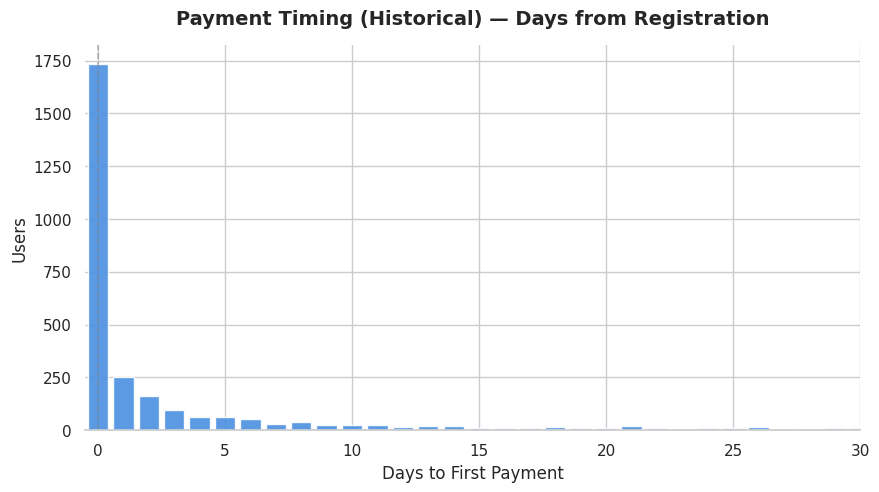

In [8]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

bins = range(0, 31)
vals = hist_conv["days_to_pay"].value_counts().sort_index()
vals = vals[vals.index <= 30]

plt.bar(vals.index, vals.values, color="#4A90E2", alpha=0.9, width=0.8)
plt.axvline(0, color="gray", linewidth=1.2, linestyle="--", alpha=0.5)

plt.title("Payment Timing (Historical) — Days from Registration", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Days to First Payment", fontsize=12)
plt.ylabel("Users", fontsize=12)
plt.xlim(-0.5, 30)

sns.despine(left=True, bottom=False)
plt.show()

In [9]:
# Test Duration Calculation

# Parameters: α = 0.05, power = 0.80, two-sided, split 50/50
# Observation window (75th pct): 7 days

expected_lift = 0.1 * baseline_conversion
variant_conversion = baseline_conversion + expected_lift

effect_size = proportion_effectsize(baseline_conversion, variant_conversion)
alpha = 0.05
power = 0.80
obs_window = 7

# Sample size calculation
sample_size = sms.NormalIndPower().solve_power(effect_size=effect_size, power=power, alpha=alpha, alternative='two-sided', ratio=1)
test_size = sample_size * 2
test_duration = test_size / daily_users + obs_window

print(f"Required sample size for each group: {(sample_size):.0f}")
print(f"Required sample size for 2 groups: {(test_size):.0f}")
print(f"Required test duration: {(test_duration):.0f} days")


Required sample size for each group: 28495
Required sample size for 2 groups: 56991
Required test duration: 16 days


### **A/B Test Results**

In [10]:
test_days = (df_test["date_reg"].max() - df_test["date_reg"].min()).days

a = df_test[df_test["match"] == 0]
b = df_test[df_test["match"] == 1]

# SRM check
a_size = len(a)
b_size = len(b)

srm_a_pct = a_size / (a_size + b_size) * 100
srm_b_pct  = b_size / (a_size + b_size) * 100

# Conversion rates
conv_a = a["date_first_payment"].notna().sum()
conv_b = b["date_first_payment"].notna().sum()

cr_a = conv_a / a_size
cr_b = conv_b / b_size
diff = cr_b - cr_a
rel_lift = (cr_b / cr_a - 1) * 100

# Perform z-stat
z_stat, p_value = proportions_ztest([conv_b, conv_a], [b_size, a_size])

actual_es = proportion_effectsize(cr_a, cr_b)
power_achieved = sms.NormalIndPower().solve_power(effect_size=actual_es, nobs1=min(a_size, b_size), alpha=0.05, alternative="two-sided")

print(f"Test period: {df_test['date_reg'].min().date()} - {df_test['date_reg'].max().date()}")
print(f"Test duration: {test_days} days")

print(f"\nGroup A:  n = {a_size:,} ({srm_a_pct:.2f}%),  conversions = {conv_a:,},  rate = {cr_a * 100:.2f}%")
print(f"Group B:  n = {b_size:,} ({srm_b_pct:.2f}%),  conversions = {conv_b:,},  rate = {cr_b  *100:.2f}%")

print(f"\nAbsolute lift: {diff * 100:.2f}%")
print(f"Relative lift: {rel_lift:.2f}%")

print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significant (α=0.05): {p_value < 0.05}")
print(f"Achieved power: {power_achieved:.4f}")

Test period: 2023-03-14 - 2023-04-18
Test duration: 34 days

Group A:  n = 62,568 (49.97%),  conversions = 3,506,  rate = 5.60%
Group B:  n = 62,649 (50.03%),  conversions = 3,731,  rate = 5.96%

Absolute lift: 0.35%
Relative lift: 6.28%

Z-statistic: 2.6681
P-value: 0.007629
Significant (α=0.05): True
Achieved power: 0.7604


In [11]:
# Reminder Segment

# Reminder exposure
b_with_rem = b[b["date_reminder"].notna()]
b_no_rem   = b[b["date_reminder"].isna()]
a_with_rem = a[a["date_reminder"].notna()]

conv_with_rem = b_with_rem['date_first_payment'].notna().mean() * 100
conv_no_rem = b_no_rem['date_first_payment'].notna().mean() * 100

print(f"Group B with reminder: {len(b_with_rem):,} ({len(b_with_rem) / b_size*100:.1f}%)")
print(f"Group A with reminder: {len(a_with_rem):,} (should be 0)")

print(f"\nConversion by reminder (Group B only):")
print(f"With reminder: {conv_with_rem:.2f}%")
print(f"Without reminder:{conv_no_rem:.2f}%")

Group B with reminder: 15,119 (24.1%)
Group A with reminder: 89 (should be 0)

Conversion by reminder (Group B only):
With reminder: 16.07%
Without reminder:2.74%


In [12]:
# Time from reminder to payment

paid_after_rem = b_with_rem[b_with_rem["date_first_payment"].notna()].copy()
paid_after_rem["days_rem_to_pay"] = (paid_after_rem["date_first_payment"] - paid_after_rem["date_reminder"]).dt.days

print(f"Days from reminder to first payment:")
print(paid_after_rem["days_rem_to_pay"].describe().round(2).to_string())

Days from reminder to first payment:
count    2430.00
mean        5.02
std        28.84
min       -39.00
25%        -1.00
50%         0.00
75%         0.00
max       266.00


In [13]:
# Segment: spent 15+ credits
a_s = a[a["date_spent_15_credits"].notna()]
b_s = b[b["date_spent_15_credits"].notna()]
z_s, p_s = proportions_ztest(
    [b_s["date_first_payment"].notna().sum(), a_s["date_first_payment"].notna().sum()],
    [len(b_s), len(a_s)]
)

print(f"Spent 15+ credits segment:")
print(f"\nGroup A:   n = {len(a_s):,}, rate = {a_s['date_first_payment'].notna().mean()*100:.2f}%")
print(f"Group B:   n = {len(b_s):,}, rate = {b_s['date_first_payment'].notna().mean()*100:.2f}%")
print(f"\nz_stat = {z_s:.3f}, p_value={p_s:.4f}")

Spent 15+ credits segment:

Group A:   n = 25,695, rate = 13.48%
Group B:   n = 25,858, rate = 14.24%

z_stat = 2.504, p_value=0.0123


In [14]:
# Funnel
print(f"Funnel:")
for grp_name, grp in (("Group A", a), ("Group B", b)):
    spent15 = grp["date_spent_15_credits"].notna().sum() / len(grp) * 100
    paid    = grp["date_first_payment"].notna().sum() / len(grp) * 100
    print(f"  {grp_name}: spent15 = {spent15:.1f}%, paid = {paid:.2f}%")

Funnel:
  Group A: spent15 = 41.1%, paid = 5.60%
  Group B: spent15 = 41.3%, paid = 5.96%


In [15]:
# Weekly conversion

df_test["week"] = df_test["date_reg"].dt.isocalendar().week
weekly = df_test.groupby(["week", "match"])["date_first_payment"].apply(
    lambda x: x.notna().mean() * 100
).unstack()

print("\nWeekly conversion rate (%):")
print(weekly.rename(columns={0:"Group A", 1:"Group B"}).to_string())


Weekly conversion rate (%):
match   Group A   Group B
week                     
11     5.621196  5.828633
12     5.610184  5.681732
13     5.436692  6.027833
14     5.539458  6.100661
15     5.927116  6.084970
16     5.022831  6.361923


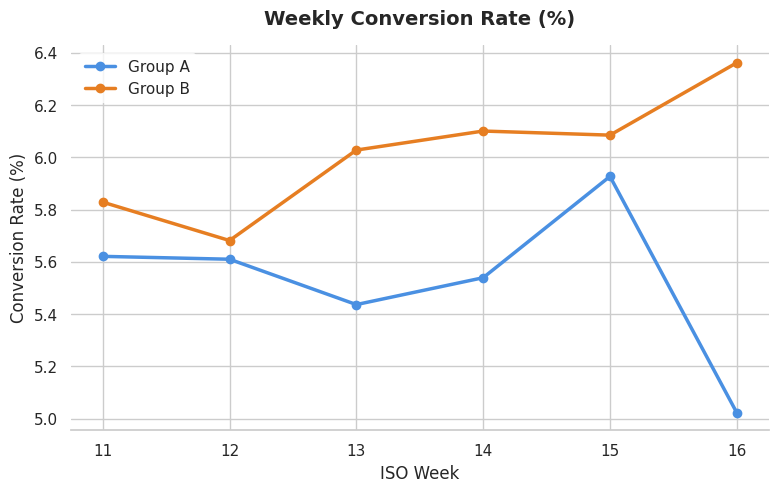

In [16]:
plt.figure(figsize=(9, 5))

weeks = weekly.index.tolist()

plt.plot(weeks, weekly[0], marker="o", color="#4A90E2", label="Group A", linewidth=2.5)
plt.plot(weeks, weekly[1], marker="o", color="#E67E22", label="Group B", linewidth=2.5)

plt.title("Weekly Conversion Rate (%)", fontsize=14, pad=15, fontweight="bold")
plt.xlabel("ISO Week", fontsize=12)
plt.ylabel("Conversion Rate (%)", fontsize=12)

plt.xticks(weeks)
plt.legend(frameon=True, facecolor="white", edgecolor="none")

sns.despine(left=True, bottom=False)
plt.savefig("weekly_plot.png", dpi=100, bbox_inches="tight")
plt.show()